In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
import cloudpickle as pickle
from regions import RectangleSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u
import glob
from astropy.io import fits

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable, _ztfcam_ccd_gain, _ztfcam_readout_noise
from lightcurvelynx.astro_utils.mag_flux import mag2flux
import sqlite3

from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable
from lightcurvelynx.obstable.fake_obs_table import FakeObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.pzflow_node import PZFlowNode
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.models.sncomso_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.astro_utils.detector_footprint import DetectorFootprint

from lightcurvelynx.graph_state import GraphState
from lightcurvelynx.simulate import compute_single_noise_free_lightcurve
from lightcurvelynx.astro_utils.noise_model import poisson_bandflux_std

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR
from lightcurvelynx.consts import GAUSS_EFF_AREA2FWHM_SQ

from lightcurvelynx.validation.lcfit import fit_single_lc

from utils.plotting_utils import convert_flux_to_njy, plot_coverage_map

In [3]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [4]:
lcdata = read_parquet('data/ztfsniadr2.parquet')

In [5]:
list2 = pd.read_csv('/Users/mi/Downloads/ztfnames',header=None)[0].to_list()

In [6]:
list1 = data.iau_name.to_list()

In [7]:
# randomly pick an SN in the data release to simulate
# ZTF20abegoix - this one looks good for paper
# ZTF19aazlsfj - also good
# random_sn = data.dropna().sample()
random_sn = data.loc[data.iau_name == "2020jny"]
random_sn

,Unnamed: 0,ztfname,redshift,redshift_err,source,t0,x0,x1,c,t0_err,...,fitquality_flag,iau_name,frac_fitted,ra_host,dec_host,mass,mass_err,restframe_gz,restframe_gz_err,d_dlr
2690,2690,ZTF20aazgtmp,0.023708,0.000021,z_gal,58993.144828,0.005328,-1.524705,-0.056194,0.159406,...,1.0,2020jny,100.0,180.743888,20.085211,9.213,0.114612,1.066697,0.019849,0.310123


In [8]:
random_lc = lcdata.loc[lcdata["ztfname"] == random_sn.ztfname.values[0]]
random_lc['lc'].iloc[0]

,mjd,filter,flux,flux_err,ZP,flag,mag,mag_err,field_id,rcid,flux_offset,offset_unc,err_scale,in_baseline
0,58131.45685,ztfg,938.89350,1248.08315,30.0,64,99.0,99.0,575,37.0,-171.27878,152.90124,1.00000,1
1,58131.46291,ztfg,-701.20079,1136.62071,30.0,64,99.0,99.0,575,37.0,-171.27878,152.90124,1.00000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,59798.16117,ztfr,-8168.96201,3532.85301,30.0,392,99.0,99.0,575,37.0,-567.64475,174.40047,1.24398,0
842,59798.16354,ztfr,8585.96939,3438.76922,30.0,392,99.0,99.0,575,37.0,-567.64475,174.40047,1.24398,0


In [9]:
obs_log = pd.read_parquet('data/ztf_observing_log_combined_w_metadata.parquet')
colmap = {"ra":"ra",
          "dec":"dec",
          "time":"mjd",
          "zp":"zp_nJy",
          "filter":"filter",
          "sky":"sky_adu",
         }

#ztf ccd size 6144 × 6160 pixel * 16
pixel_scale = 1.01 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
rect_region = RectangleSkyRegion(center=center, width=4*6144.* pixel_scale * u.arcsec, 
                                 height=4*6160.* pixel_scale * u.arcsec, angle=0.0 * u.deg)
ztf_fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

ztf_obstable = ZTFObsTable(obs_log,colmap=colmap,detector_footprint=ztf_fp)

In [10]:
ra, dec = random_sn.ra.values[0], random_sn.dec.values[0]
idx = ztf_obstable.range_search(ra,dec)
table = ztf_obstable._table.iloc[idx]
table

,time,band,fieldid,fieldra,fielddec,rcid,maglimit,zp_abmag,gain,expid,...,exptime,fwhm,obsdate,scibckgnd,ra,dec,maglim,zp,sky,obsmjd
1297,58290.191406,ztfg,575,3.147249,0.33074,18,20.476805,26.151114,6.2,53619111,...,30.0,2.488525,2018-06-21 04:35:12.755,82.5505,180.324083,18.95,20.0166,20.284435,1397.930540,58290.191120
1422,58290.253906,ztfr,575,3.147249,0.33074,17,20.316097,26.110249,6.2,53625289,...,30.0,2.214460,2018-06-21 06:04:10.120,219.2490,180.324083,18.95,19.7776,21.062450,2557.576992,58290.252895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518639,59269.398438,ztfi,575,3.147249,0.33074,0,20.725780,25.660049,6.1,151540010,...,30.0,1.647275,2021-02-24 09:36:09.905,247.3870,180.324083,18.95,20.0751,31.885155,1146.441494,59269.400115
519400,59270.339844,ztfr,575,3.147249,0.33074,22,20.393116,26.292171,6.3,151634013,...,30.0,2.026150,2021-02-25 08:09:48.172,258.9085,180.324083,18.95,19.8490,17.813109,3754.037805,59270.340141


In [11]:
obs_log_allccd = pd.read_parquet('ztfsniadr2/tables/observing_logs.parquet')
obs_log_allccd = obs_log_allccd[obs_log_allccd["expid"].isin(table.expid)]
obs_log_allccd

,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp,gain,expid,infobits,skynoise
82277,58290.191406,ztfg,575,3.147249,0.33074,18,20.322866,26.137365,6.2,53619111,0,42.347675
82278,58290.191406,ztfg,575,3.147249,0.33074,19,20.367065,26.122066,6.2,53619111,0,40.089481
...,...,...,...,...,...,...,...,...,...,...,...,...
32632768,59270.339844,ztfr,575,3.147249,0.33074,47,20.396891,26.348890,6.3,151634013,0,48.065102
32632769,59270.339844,ztfr,575,3.147249,0.33074,42,20.437506,26.418007,6.1,151634013,0,49.343559


In [12]:
df1 = table
df2 = random_lc['lc'].iloc[0]
df3 = obs_log_allccd

In [13]:
# match the rcid for that sn
dflist = []
for i,row in df2.drop_duplicates(['field_id','rcid']).iterrows():
    df = df3.loc[(df3.fieldid == row['field_id']) & (df3.rcid == row['rcid'])]
    dflist.append(df)
obs_log = pd.concat(dflist)
obs_log

,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp,gain,expid,infobits,skynoise
82330,58290.191406,ztfg,575,3.147249,0.330740,37,20.411980,26.116980,6.2,53619111,0,38.285114
90322,58290.253906,ztfr,575,3.147249,0.330740,37,20.334553,26.107553,6.2,53625289,0,40.759636
...,...,...,...,...,...,...,...,...,...,...,...,...
32045589,59256.355469,ztfr,1620,3.100007,0.393572,0,21.502792,26.164793,6.1,150235403,0,14.649752
32572083,59269.292969,ztfr,1620,3.100007,0.393572,0,20.760176,26.167175,6.1,151529188,0,29.095768


In [14]:
con = sqlite3.connect("data/ztf_metadata_latest.db")
sql_query = "SELECT * FROM exposures"
metadata_table = pd.read_sql_query(sql_query, con)
metadata_table = metadata_table.replace("", np.nan)
metadata_table = metadata_table.dropna(subset=["fwhm"])
metadata_table.columns

/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_11907/2534340399.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata_table = metadata_table.replace("", np.nan)


Index(['expid', 'field', 'filter', 'obsdate', 'ra', 'dec', 'exptime',
       'airmass', 'infobits', 'dr', 'numsci', 'numdiff', 'fwhm', 'maglim',
       'scibckgnd', 'ellip', 'ellippa'],
      dtype='object')

In [15]:
obs_log["filter"] = obs_log.apply(lambda row: row["band"][-1],axis=1)
obs_log = pd.merge(obs_log, metadata_table[["expid","filter","exptime","fwhm","obsdate","scibckgnd","ra","dec","maglim"]],on=["filter","expid"])
gain = _ztfcam_ccd_gain
obs_log["zp_nJy"] = mag2flux(obs_log["zp"].values + 2.5*np.log10(gain))
obs_log = obs_log.rename(columns={"zp":"zp_abmag"})
def compute_sky(row):
    gain = _ztfcam_ccd_gain
    nea = GAUSS_EFF_AREA2FWHM_SQ * (row["fwhm"]) ** 2
    flux = np.power(10., -0.4*(row['maglimit'] - row['zp_abmag'])) * gain
    sky = (flux**2 / 25 - flux - _ztfcam_readout_noise**2 * nea) / nea / gain
    return sky    
obs_log["sky_adu"] = obs_log.apply(compute_sky,axis=1)
obs_log

,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp_abmag,gain,expid,...,filter,exptime,fwhm,obsdate,scibckgnd,ra,dec,maglim,zp_nJy,sky_adu
0,58290.191406,ztfg,575,3.147249,0.330740,37,20.411980,26.116980,6.2,53619111,...,g,30.0,2.488525,2018-06-21 04:35:12.755,82.5505,180.324083,18.95,20.0166,20.932277,623.587015
1,58290.253906,ztfr,575,3.147249,0.330740,37,20.334553,26.107553,6.2,53625289,...,r,30.0,2.214460,2018-06-21 06:04:10.120,219.2490,180.324083,18.95,19.7776,21.114797,898.215763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,59256.355469,ztfr,1620,3.100007,0.393572,0,21.502792,26.164793,6.1,150235403,...,r,30.0,1.908720,2021-02-11 08:29:49.529,417.3925,177.617292,22.55,21.0292,20.030468,141.971390
689,59269.292969,ztfr,1620,3.100007,0.393572,0,20.760176,26.167175,6.1,151529188,...,r,30.0,1.706595,2021-02-24 07:00:19.753,414.6525,177.617292,22.55,20.3191,19.986567,762.871687


In [16]:
colmap = {"ra":"ra",
          "dec":"dec",
          "time":"mjd",
          "zp":"zp_nJy",
          "filter":"filter",
          "sky":"sky_adu",
         }

#ztf ccd size 6144 × 6160 pixel * 16
pixel_scale = 1.01 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
rect_region = RectangleSkyRegion(center=center, width=4*6144.* pixel_scale * u.arcsec, 
                                 height=4*6160.* pixel_scale * u.arcsec, angle=0.0 * u.deg)
ztf_fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

ztf_obstable = ZTFObsTable(obs_log,colmap=colmap,detector_footprint=ztf_fp)
ztf_obstable.survey_values["zp_err_mag"] = 0.001

t_min, t_max = ztf_obstable.time_bounds()
print(f"Loaded OpSim with {len(ztf_obstable)} rows and times [{t_min}, {t_max}]")

# sky_coverage = ztf_obstable.estimate_coverage(use_footprint=True)
# print(f"The total sky coverage is {sky_coverage} square degrees")

passband_group = PassbandGroup.from_preset(preset="ZTF", filters=["g", "r", "i"])
print(f"Loaded Passbands: {passband_group}")

Loaded OpSim with 690 rows and times [58290.19140625, 59270.33984375]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i


In [17]:
H0 = 70.0
Omega_m = 0.3

host = SNIaHost(
    ra = random_sn.ra_host,
    dec = random_sn.dec,
    hostmass= random_sn.mass,
    redshift=random_sn.redshift,
    node_label="host",
)

In [18]:
sncosmo_modelname = "salt3"
source = SncosmoWrapperModel(
    sncosmo_modelname,
    t0=random_sn.t0.values[0],
    x0=random_sn.x0.values[0],
    x1=random_sn.x1.values[0],
    c=random_sn.c.values[0],
    ra=random_sn.ra.values[0],
    dec=random_sn.dec.values[0],
    redshift=random_sn.redshift.values[0],
    node_label="source",
)
    
mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)

# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", frame='observer', ebv=mwextinction, Rv=3.1)
source.add_effect(ext_effect)


In [19]:
nsntotal = 100
lightcurves = simulate_lightcurves(source, int(nsntotal), ztf_obstable, passband_group, 
                                   obstable_save_cols=["expid","zp_nJy","scibckgnd","skynoise",
                                                       "fwhm","maglimit","maglim","sky_adu"])
lightcurves

Simulating: 100%|███████████████████████████| 100/100 [00:00<00:00, 154.37obj/s]


id          ra        dec  nobs            t0         z  \
0    0  180.743751  20.085418   690  58993.144828  0.023708   
1    1  180.743751  20.085418   690  58993.144828  0.023708   
..  ..         ...        ...   ...           ...       ...   
98  98  180.743751  20.085418   690  58993.144828  0.023708   
99  99  180.743751  20.085418   690  58993.144828  0.023708   

                                               params  \
0   {'source.ra': 180.743751, 'source.dec': 20.085...   
1   {'source.ra': 180.743751, 'source.dec': 20.085...   
..                                                ...   
98  {'source.ra': 180.743751, 'source.dec': 20.085...   
99  {'source.ra': 180.743751, 'source.dec': 20.085...   

                                           lightcurve  
0   [{mjd: 58290.191406, filter: 'g', flux: 13184....  
1   [{mjd: 58290.191406, filter: 'g', flux: -938.8...  
..                                                ...  
98  [{mjd: 58290.191406, filter: 'g', flux: 3430.6...  
99  [{mjd: 58290.191406, filter: 'g', flux: 4940.4...  

[100 rows x 8 columns]

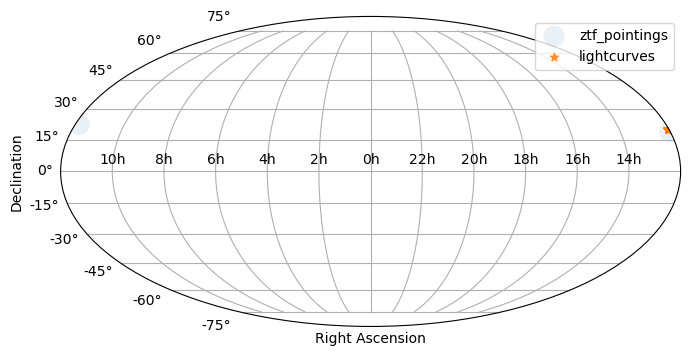

In [20]:
plot_coverage_map(ztf_obstable,lightcurves,plot_na_location=False,plot_all_location=True)

In [21]:
lightcurves = lightcurves.rename(columns={"lightcurve":"lc"})
lightcurves = lightcurves.dropna(subset="lc")

In [22]:
lightcurves['lc.snr'] = lightcurves['lc.flux']/lightcurves['lc.fluxerr']
detection_snr_thres = 5.
lightcurves['lc.detection_flag'] = lightcurves['lc.snr'] > detection_snr_thres
# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lc.is_saturated==False").dropna()
# drop non detection
lightcurves_after_detection = lightcurves_after_drop_sat.query("lc.detection_flag == True").dropna()

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


In [23]:
def filter_flags(lc_flag, flags_to_exclude=[], flags_to_include=[]):
    pass_filter = True
    if len(flags_to_include)>0:
        pass_filter &= np.all([lc_flag & flag != 0 for flag in flags_to_include])
    if len(flags_to_exclude)>0:
        pass_filter &= np.all([lc_flag & flag == 0 for flag in flags_to_exclude])
    return pass_filter

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:321: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(nested, new_nested_series)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/utils/plotting.py:112: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.

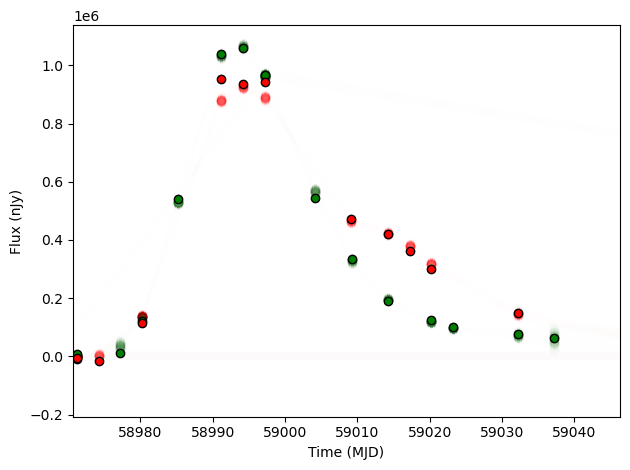

In [24]:
sncosmo_modelname = "salt3"
random_ids = lightcurves.id.sample(1).values
colormap = {'g':'g',
            'r':'r',
            'i':'purple',}

ax = plt.subplot()
        
# lc_all = lightcurves_after_detection
lc_all = lightcurves.dropna(subset=["lc"])

ax = plot_lightcurves(
    fluxes=lc_all["lc.flux"],
    times=lc_all["lc.mjd"],
    filters=lc_all["lc.filter"],
    colormap=colormap,
    underlying_model=None,#noise_free_lcs,
    alpha = 0.007,
    ax = ax,
)


plt.ylabel('Flux (nJy)')

lc_plot = random_lc
lc_plot["lc.pass_flag_filter"] = lc_plot["lc.flag"].apply(filter_flags,flags_to_exclude=[1,2,4,8,16,32],flags_to_include=[])
lc_plot = lc_plot.query("lc.pass_flag_filter == True")

#plot the data
lc_plot["lc.flux"], lc_plot["lc.flux_err"] = convert_flux_to_njy(lc_plot["lc.flux"],lc_plot["lc.flux_err"],zp=30.)

plot_lightcurves(
    fluxes=lc_plot["lc.flux"],
    times=lc_plot["lc.mjd"],
    fluxerrs=lc_plot["lc.flux_err"],
    filters=[x[-1] for x in lc_plot["lc.filter"]],
    colormap=colormap,
    ax = ax,
    marker = "o",
    markeredgecolor = "k",
)

t_min, t_max = -2 + random_sn.t0.values[0] - 20*(1+random_sn.redshift.values[0]), 2 + random_sn.t0.values[0] + 50*(1+random_sn.redshift.values[0])
plt.xlim((t_min,t_max))
plt.gca().get_legend().remove()
# plt.ylim((-5e4,mag2flux(17)))
plt.tight_layout()

# plt.savefig("paper_figs/example_lc.png")

In [25]:
lynx_lc = lc_all.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


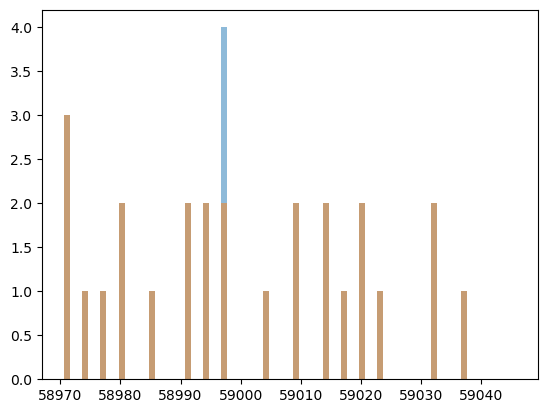

In [26]:
bins = np.arange(t_min,t_max,1)
plt.hist(lynx_lc.mjd,bins=bins,alpha=0.5)
plt.hist(ztf_lc.mjd,bins=bins,alpha=0.5)
plt.show()

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: 

Text(0, 0.5, 'flux_sim/flux_data')

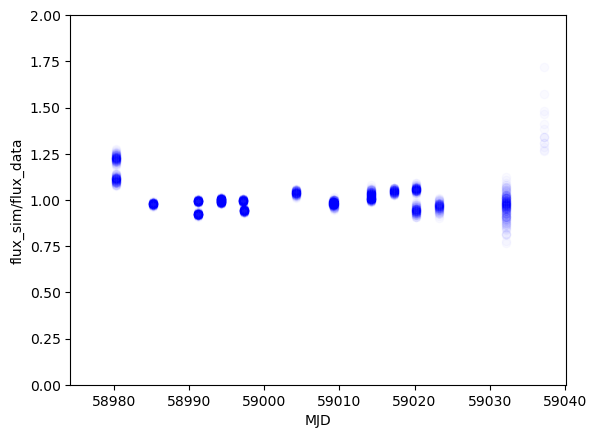

In [27]:
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

for i in range(0,len(lightcurves)):
    lynx_lc = lc_all.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[i]
    
    merged = pd.merge_asof(
        lynx_lc.sort_values('mjd'),
        ztf_lc.sort_values('mjd'),
        on='mjd',
        direction='nearest',
        tolerance=0.01,
        suffixes = ('_lynx','_ztf'),
    )
    merged = merged.dropna().loc[merged.dropna().detection_flag]
    plt.plot(merged.mjd,merged.flux_lynx/merged.flux_ztf,'o',alpha=0.02,color='b')
plt.ylim((0,2))
plt.xlabel('MJD')
plt.ylabel("flux_sim/flux_data")

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: 

Text(0, 0.5, 'fluxerr_sim/fluxerr_data')

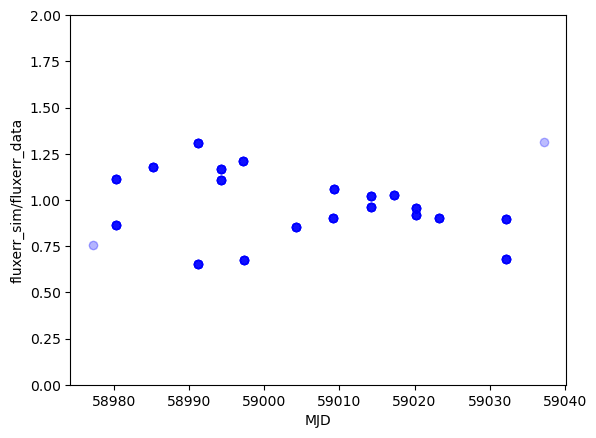

In [28]:
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

for i in range(0,len(lightcurves)):
    lynx_lc = lc_all.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[i]
    
    merged = pd.merge_asof(
        lynx_lc.sort_values('mjd'),
        ztf_lc.sort_values('mjd'),
        on='mjd',
        direction='nearest',
        tolerance=0.01,
        suffixes = ('_lynx','_ztf'),
    )
    merged = merged.dropna().loc[merged.dropna().detection_flag]
    plt.plot(merged.mjd,merged.fluxerr/merged.flux_err,'o',color='b',alpha=0.02)
plt.ylim((0,2))
plt.xlabel('MJD')
plt.ylabel("fluxerr_sim/fluxerr_data")

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: 

Text(0, 0.5, 'snr_sim/snr_data')

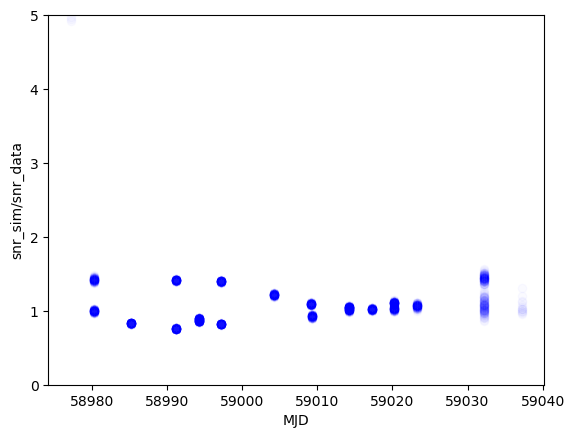

In [29]:
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

for i in range(0,len(lightcurves)):
    lynx_lc = lc_all.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[i]
    
    merged = pd.merge_asof(
        lynx_lc.sort_values('mjd'),
        ztf_lc.sort_values('mjd'),
        on='mjd',
        direction='nearest',
        tolerance=0.01,
        suffixes = ('_lynx','_ztf'),
    )
    merged = merged.dropna().loc[merged.dropna().detection_flag]
    plt.plot(merged.mjd,(merged.flux_lynx/merged.fluxerr)/(merged.flux_ztf/merged.flux_err),'o',color='b',alpha=0.02)
plt.ylim((0,5))
plt.xlabel('MJD')
plt.ylabel("snr_sim/snr_data")

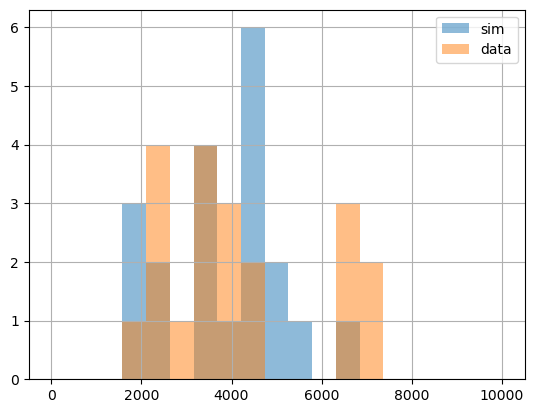

In [30]:
(merged.fluxerr).hist(bins=np.linspace(0,1e4,20),alpha=0.5,label='sim')
(merged.flux_err).hist(bins=np.linspace(0,1e4,20),alpha=0.5,label='data')
plt.legend()

In [31]:
merged.columns

Index(['mjd', 'filter_lynx', 'flux_lynx', 'fluxerr', 'flux_perfect',
       'survey_idx', 'is_saturated', 'expid', 'zp_nJy', 'scibckgnd',
       'skynoise', 'fwhm', 'maglimit', 'maglim', 'sky_adu', 'snr',
       'detection_flag', 'filter_ztf', 'flux_ztf', 'flux_err', 'ZP', 'flag',
       'mag', 'mag_err', 'field_id', 'rcid', 'flux_offset', 'offset_unc',
       'err_scale', 'in_baseline', 'pass_flag_filter'],
      dtype='object')

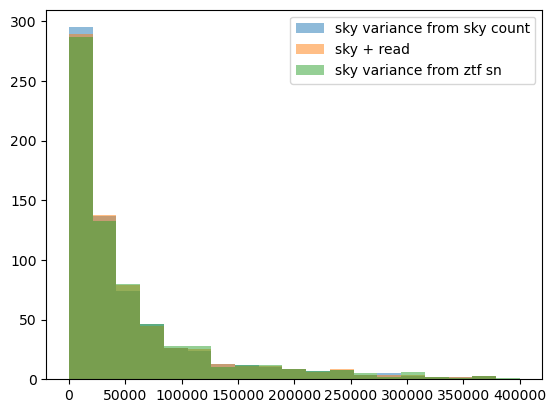

In [32]:
from lightcurvelynx.consts import GAUSS_EFF_AREA2FWHM_SQ
nea = GAUSS_EFF_AREA2FWHM_SQ * (obs_log["fwhm"]) ** 2
sky_variance = obs_log["sky_adu"]*6.2*nea
readout_noise = 8.
sky_read_variance = sky_variance + readout_noise**2 * nea

# plt.plot(obs_log["scibckgnd"]*6.2*nea,obs_log["skynoise"]**2,'o',alpha=0.5)
# plt.ylim(plt.xlim()[:])
bins = np.linspace(0,4e5,20)
plt.hist(sky_variance,bins=bins,alpha=0.5,label='sky variance from sky count')
plt.hist(sky_read_variance, bins=bins, alpha=0.5, label='sky + read')
plt.hist((obs_log["skynoise"]*6.2)**2,bins=bins,alpha=0.5,label='sky variance from ztf sn') #skynoise = 1/5 * 10^(-0.4(maglim - magzp)) in ADU
plt.legend()

In [33]:
def ztfsn_noise_cal(skynoise, flux, zp):
    variance = (skynoise*gain)**2 + flux/zp  #skynoise is in ADU
    return np.sqrt(variance)*zp

In [34]:
ztf_noise = ztfsn_noise_cal(merged['skynoise'],merged['flux_perfect'],merged['zp_nJy'])

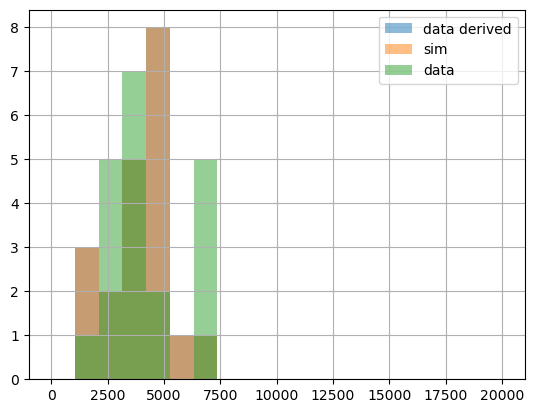

In [35]:
bins = np.linspace(0,2e4,20)
ztf_noise.hist(bins = bins,label="data derived",alpha=0.5)
merged["fluxerr"].hist(bins = bins,label="sim",alpha=0.5)
merged["flux_err"].hist(bins = bins,label="data",alpha=0.5)
plt.legend()

In [36]:
fp = pd.read_csv('/Users/mi/Downloads/2020jny_lc.txt',comment='#',sep=" ")

In [37]:
for c in fp.columns:
    fp = fp.rename(columns={c:c.split(',')[0]})

In [38]:
fp.columns

Index(['Unnamed: 0', 'index', 'field', 'ccdid', 'qid', 'filter', 'pid',
       'infobitssci', 'sciinpseeing', 'scibckgnd', 'scisigpix', 'zpmaginpsci',
       'zpmaginpsciunc', 'zpmaginpscirms', 'clrcoeff', 'clrcoeffunc',
       'ncalmatches', 'exptime', 'adpctdif1', 'adpctdif2', 'diffmaglim',
       'zpdiff', 'programid', 'jd', 'rfid', 'forcediffimflux',
       'forcediffimfluxunc', 'forcediffimsnr', 'forcediffimchisq',
       'forcediffimfluxap', 'forcediffimfluxuncap', 'forcediffimsnrap',
       'aperturecorr', 'dnearestrefsrc', 'nearestrefmag', 'nearestrefmagunc',
       'nearestrefchi', 'nearestrefsharp', 'refjdstart', 'refjdend',
       'procstatus'],
      dtype='object')

In [39]:
# rid = (ccdid - 1)*4 +qid
fp['rid'] = (fp['ccdid'] - 1)*4 + fp['qid']
fp['mjd'] = fp['jd'] - 2_400_000.5
fp['filter'] = [x[-1] for x in fp['filter']]

In [40]:
fp

,Unnamed: 0,index,field,ccdid,qid,filter,pid,infobitssci,sciinpseeing,scibckgnd,...,dnearestrefsrc,nearestrefmag,nearestrefmagunc,nearestrefchi,nearestrefsharp,refjdstart,refjdend,procstatus,rid,mjd
0,NaN,0,575,10,1,g,874193103715,0,1.8049,93.0235,...,0.953303,18.582,0.086,6.912,0.45,2.458167e+06,2.458431e+06,0,37,58628.193102
1,NaN,1,575,10,1,g,874194003715,0,1.7596,93.3396,...,0.953303,18.582,0.086,6.912,0.45,2.458167e+06,2.458431e+06,0,37,58628.194005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,NaN,497,575,10,1,g,1782531363715,0,1.9268,108.5660,...,0.953303,18.582,0.086,6.912,0.45,2.458167e+06,2.458431e+06,0,37,59536.531366
498,NaN,498,575,10,1,g,1796478373715,0,2.1542,102.8850,...,0.953303,18.582,0.086,6.912,0.45,2.458167e+06,2.458431e+06,0,37,59550.478380


In [41]:
lynx_lc = lightcurves['lc'].iloc[0]
ztf_lc = random_lc['lc'].iloc[0]
ztf_lc['filter'] = [x[-1] for x in ztf_lc['filter']]

In [42]:
lynx_lc

,mjd,filter,flux,fluxerr,flux_perfect,survey_idx,is_saturated,expid,zp_nJy,scibckgnd,skynoise,fwhm,maglimit,maglim,sky_adu,snr,detection_flag
0,58290.191406,g,13184.230134,4916.037587,0.0,0,False,53619111,20.932277,82.5505,38.285114,2.488525,20.411980,20.0166,623.587015,2.681881,False
1,58290.253906,r,-3733.184592,5282.864126,0.0,0,False,53625289,21.114797,219.2490,40.759636,2.214460,20.334553,19.7776,898.215763,-0.706659,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,59256.355469,r,1204.019340,1768.551606,0.0,0,False,150235403,20.030468,417.3925,14.649752,1.908720,21.502792,21.0292,141.971390,0.680794,False
689,59269.292969,r,1750.999793,3555.134432,0.0,0,False,151529188,19.986567,414.6525,29.095768,1.706595,20.760176,20.3191,762.871687,0.492527,False


In [43]:
ztf_lc

,mjd,filter,flux,flux_err,ZP,flag,mag,mag_err,field_id,rcid,flux_offset,offset_unc,err_scale,in_baseline,pass_flag_filter
0,58131.45685,g,938.89350,1248.08315,30.0,64,99.0,99.0,575,37.0,-171.27878,152.90124,1.00000,1,True
1,58131.46291,g,-701.20079,1136.62071,30.0,64,99.0,99.0,575,37.0,-171.27878,152.90124,1.00000,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,59798.16117,r,-8168.96201,3532.85301,30.0,392,99.0,99.0,575,37.0,-567.64475,174.40047,1.24398,0,False
842,59798.16354,r,8585.96939,3438.76922,30.0,392,99.0,99.0,575,37.0,-567.64475,174.40047,1.24398,0,False


In [44]:
ztf_lc["flux"], ztf_lc["flux_err"] = convert_flux_to_njy(ztf_lc["flux"],ztf_lc["flux_err"],zp=30.)
ztf_lc = ztf_lc.rename(columns={'flux_err':'fluxerr'})

In [45]:
merged = pd.merge_asof(
    ztf_lc.sort_values('mjd'),
    lynx_lc.sort_values('mjd'),
    on='mjd',
    by=['filter'],
    direction='nearest',
    tolerance=0.01,
    suffixes = ('_ztf','_lynx'),
)
merged = merged.dropna()

In [46]:
merged_all = pd.merge_asof(
    fp.sort_values('mjd'),
    merged.sort_values('mjd'),
    on='mjd',
    by=['filter'],
    direction='nearest',
    tolerance=0.01,
    suffixes = ('_fp','_merged'),
)

In [47]:
merged_all = merged_all[merged_all.columns[1:]]
merged_all = merged_all.dropna()

In [48]:
merged_all

,index,field,ccdid,qid,filter,pid,infobitssci,sciinpseeing,scibckgnd_fp,scisigpix,...,expid,zp_nJy,scibckgnd_merged,skynoise,fwhm,maglimit,maglim,sky_adu,snr,detection_flag
0,0,575,10,1,g,874193103715,0,1.8049,93.0235,4.97620,...,87419310.0,21.224431,79.85250,11.413801,1.892580,21.710930,21.08520,82.152762,0.106987,False
1,1,575,10,1,g,874194003715,0,1.7596,93.3396,5.11011,...,87419400.0,21.388147,79.89935,10.428707,1.864775,21.800587,21.18125,68.627348,-1.812701,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,575,10,1,g,1514489403715,0,1.8618,112.7020,6.64677,...,151448940.0,17.732992,97.25800,17.069878,1.968465,21.469065,20.74720,185.690168,-1.782563,False
396,396,575,10,1,r,1516340133715,0,2.0717,250.6770,13.74020,...,151634013.0,17.974304,258.90850,45.397270,2.026150,20.392391,19.84900,1338.731299,-0.798710,False


In [49]:
merged_all.columns

Index(['index', 'field', 'ccdid', 'qid', 'filter', 'pid', 'infobitssci',
       'sciinpseeing', 'scibckgnd_fp', 'scisigpix', 'zpmaginpsci',
       'zpmaginpsciunc', 'zpmaginpscirms', 'clrcoeff', 'clrcoeffunc',
       'ncalmatches', 'exptime', 'adpctdif1', 'adpctdif2', 'diffmaglim',
       'zpdiff', 'programid', 'jd', 'rfid', 'forcediffimflux',
       'forcediffimfluxunc', 'forcediffimsnr', 'forcediffimchisq',
       'forcediffimfluxap', 'forcediffimfluxuncap', 'forcediffimsnrap',
       'aperturecorr', 'dnearestrefsrc', 'nearestrefmag', 'nearestrefmagunc',
       'nearestrefchi', 'nearestrefsharp', 'refjdstart', 'refjdend',
       'procstatus', 'rid', 'mjd', 'flux_ztf', 'fluxerr_ztf', 'ZP', 'flag',
       'mag', 'mag_err', 'field_id', 'rcid', 'flux_offset', 'offset_unc',
       'err_scale', 'in_baseline', 'pass_flag_filter', 'flux_lynx',
       'fluxerr_lynx', 'flux_perfect', 'survey_idx', 'is_saturated', 'expid',
       'zp_nJy', 'scibckgnd_merged', 'skynoise', 'fwhm', 'maglimit', 'ma

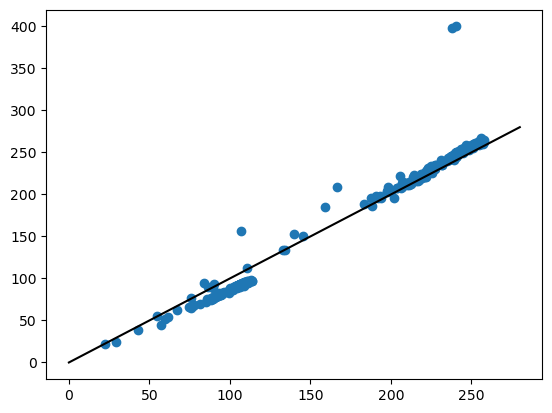

In [50]:
plt.scatter(merged_all['scibckgnd_fp'],merged_all['scibckgnd_merged'])
plt.plot([0,280],[0,280],color='k')

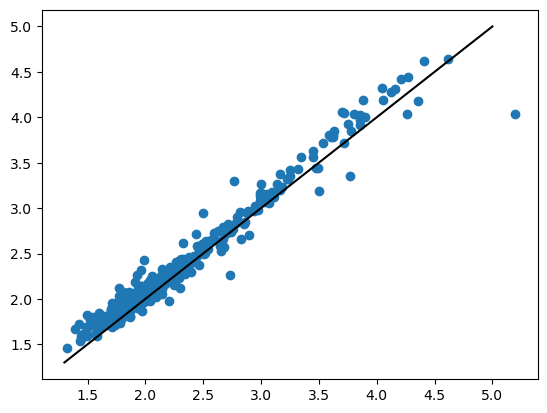

In [51]:
plt.scatter(merged_all['sciinpseeing'],merged_all['fwhm'])
plt.plot([1.3,5],[1.3,5],color='k')

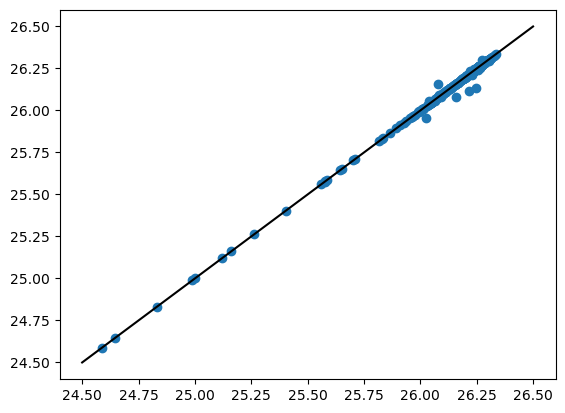

In [52]:
gain=6.2
plt.scatter(merged_all['zpmaginpsci'],flux2mag(merged_all['zp_nJy'])-2.5*np.log10(gain))
plt.plot([24.5,26.5],[24.5,26.5],color='k')

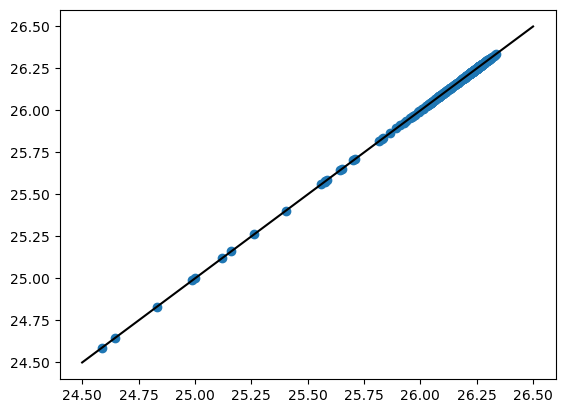

In [53]:
plt.scatter(merged_all['zpmaginpsci'],merged_all['zpdiff'])
plt.plot([24.5,26.5],[24.5,26.5],color='k')

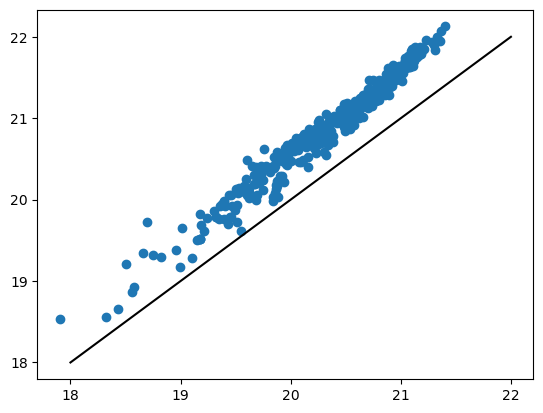

In [54]:
plt.scatter(merged_all['maglim'],merged_all['maglimit'])
plt.plot([18,22],[18,22],color='k')

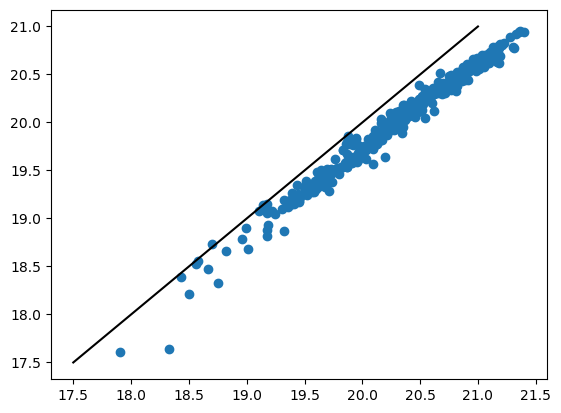

In [55]:
plt.scatter(merged_all['maglim'],merged_all['diffmaglim'])
plt.plot([17.5,21],[17.5,21],color='k')

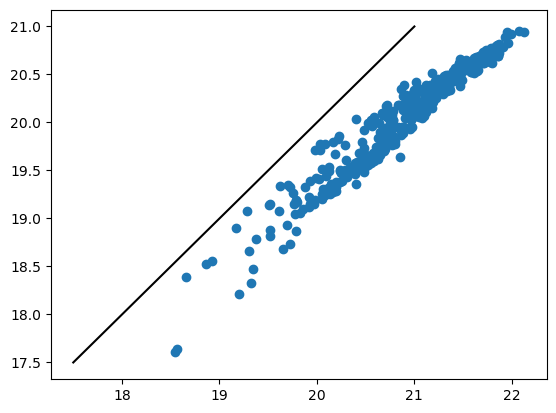

In [56]:
plt.scatter(merged_all['maglimit'],merged_all['diffmaglim'])
plt.plot([17.5,21],[17.5,21],color='k')

In [57]:
print(merged_all['maglim'].mean(),merged_all['maglimit'].mean(),merged_all['diffmaglim'].mean())

20.341542125984255 20.881424 20.034789238845143


In [58]:
flux_fp = merged_all['forcediffimflux']*gain*merged_all['zp_nJy']
fluxerr_fp = merged_all['forcediffimfluxunc']*gain*merged_all['zp_nJy']

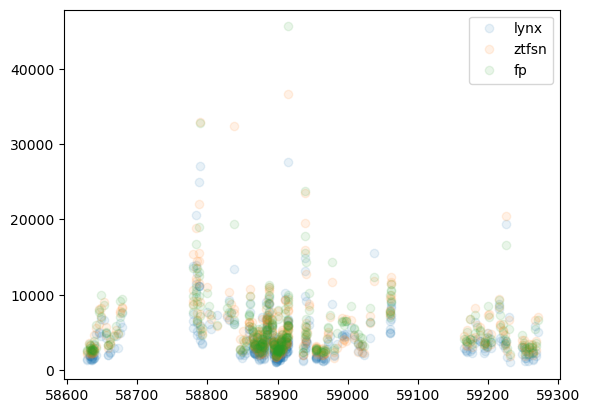

In [59]:
plt.plot(merged_all['mjd'],merged_all['fluxerr_lynx'],'o',alpha=0.1,label='lynx')
plt.plot(merged_all['mjd'],merged_all['fluxerr_ztf'],'o',alpha=0.1,label='ztfsn')
plt.plot(merged_all['mjd'],fluxerr_fp,'o',alpha=0.1,label='fp')
plt.legend()

In [60]:
from typing import Union, Sequence, Optional
import numpy as np
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import get_body, GeocentricTrueEcliptic, EarthLocation, solar_system_ephemeris

def moon_phase_from_mjd(
    mjd: Union[float, Sequence[float]],
    location: Optional[EarthLocation] = None,
    ephemeris: str = "builtin",  # or 'de432s', etc.
):
    """
    Returns illuminated fraction, phase angle, and phase name for given MJD(s).

    Parameters
    ----------
    mjd : float or array-like
        Modified Julian Date(s), UTC.
    location : EarthLocation or None
        If provided, compute topocentric positions. Otherwise geocentric.
    ephemeris : str
        Ephemeris to use (e.g., 'builtin', 'de432s').

    Returns
    -------
    dict with keys:
      'illum' : ndarray, illuminated fraction [0..1]
      'phase_angle_deg' : ndarray, Sun–Earth–Moon angle in degrees (0=new, 180=full)
      'name' : list[str], human-readable phase names
    """
    t = Time(mjd, format="mjd", scale="utc")
    with solar_system_ephemeris.set(ephemeris):
        sun = get_body("sun", t, location=location)    # apparent GCRS
        moon = get_body("moon", t, location=location)  # apparent GCRS

    # Phase angle ψ = Sun–Moon separation as seen from Earth
    psi = sun.separation(moon)
    illum = 0.5 * (1 - np.cos(psi.to_value(u.rad)))  # fraction illuminated

    # Waxing vs waning via ecliptic longitudes
    ecl = GeocentricTrueEcliptic(obstime=t)
    sun_ecl = sun.transform_to(ecl)
    moon_ecl = moon.transform_to(ecl)
    dlon = (moon_ecl.lon - sun_ecl.lon).wrap_at(180 * u.deg).to_value(u.deg)

    ang = psi.to_value(u.deg)
    waxing = dlon > 0

    def phase_name(a, w):
        if a < 10:
            return "New Moon"
        elif a < 80:
            return "Waxing Crescent" if w else "Waning Crescent"
        elif a < 100:
            return "First Quarter" if w else "Last Quarter"
        elif a < 170:
            return "Waxing Gibbous" if w else "Waning Gibbous"
        else:
            return "Full Moon"

    ang_arr = np.atleast_1d(ang)
    wax_arr = np.atleast_1d(waxing)
    names = [phase_name(a, w) for a, w in zip(ang_arr, wax_arr)]

    return {
        "illum": np.atleast_1d(illum),
        "phase_angle_deg": ang_arr,
        "name": names if ang_arr.size > 1 else names[0],
    }

# Example (geocentric):
# res = moon_phase_from_mjd(59712.3482986)
# print(res["illum"][0], res["phase_angle_deg"][0], res["name"])

# Example (topocentric from Palomar):
# palomar = EarthLocation(lat=33.3573*u.deg, lon=-116.8598*u.deg, height=1668*u.m)
# res = moon_phase_from_mjd(59712.3482986, location=palomar, ephemeris="de432s")


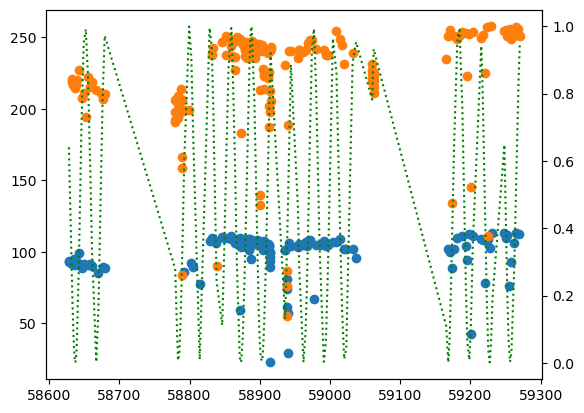

In [61]:
idxg = merged_all['filter'] == 'g'
idxr = merged_all['filter'] == 'r'
moon_phase = moon_phase_from_mjd(merged_all['mjd'])["illum"]
for idx in [idxg,idxr]:
    ax = plt.subplot()
    ax.plot(merged_all[idx]['mjd'],merged_all[idx]['scibckgnd_fp'],'o')
ax2 = ax.twinx()
ax2.plot(merged_all['mjd'],moon_phase,':',c='g')

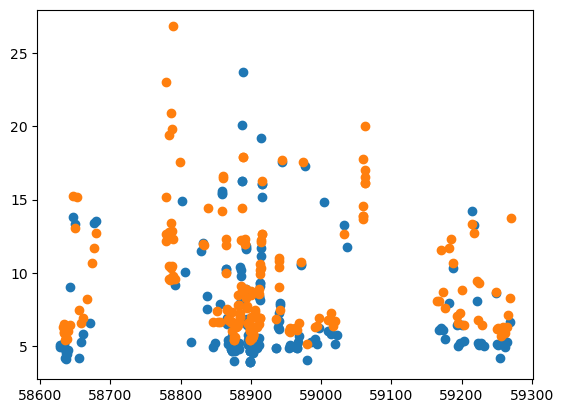

In [62]:
idxg = merged_all['filter'] == 'g'
idxr = merged_all['filter'] == 'r'
for idx in [idxg,idxr]:
    plt.plot(merged_all[idx]['mjd'],merged_all[idx]['scisigpix'],'o')

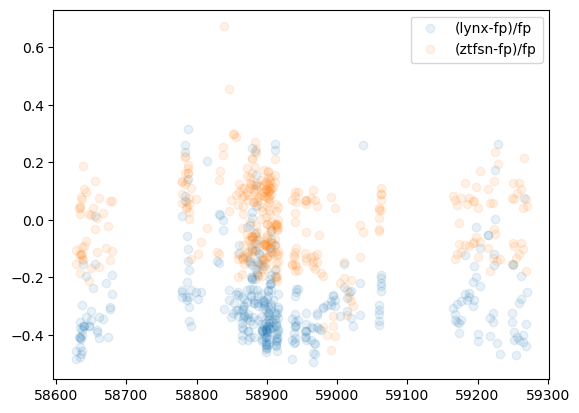

In [63]:
plt.plot(merged_all['mjd'],(merged_all['fluxerr_lynx'] - fluxerr_fp)/fluxerr_fp,'o',alpha=0.1,label='(lynx-fp)/fp')
plt.plot(merged_all['mjd'],(merged_all['fluxerr_ztf'] - fluxerr_fp)/fluxerr_fp,'o',alpha=0.1,label='(ztfsn-fp)/fp')
plt.legend()

<ErrorbarContainer object of 3 artists>

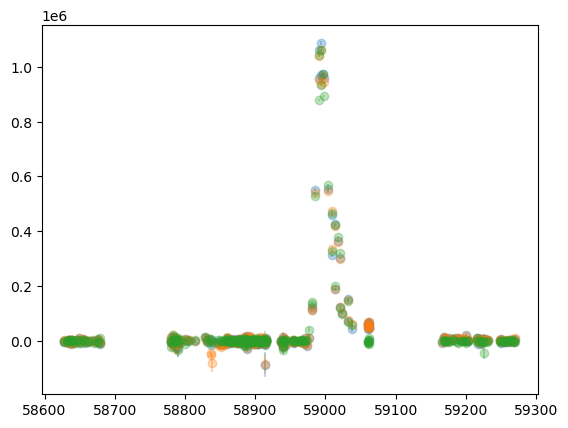

In [64]:
plt.errorbar(merged_all['mjd'],flux_fp, yerr=fluxerr_fp, fmt='o',alpha=0.3)
plt.errorbar(merged_all['mjd'],merged_all['flux_ztf'],yerr=merged_all['fluxerr_ztf'],fmt='o',alpha=0.3)
plt.errorbar(merged_all['mjd'],merged_all['flux_lynx'],yerr=merged_all['fluxerr_lynx'],fmt='o',alpha=0.3)

<Axes: >

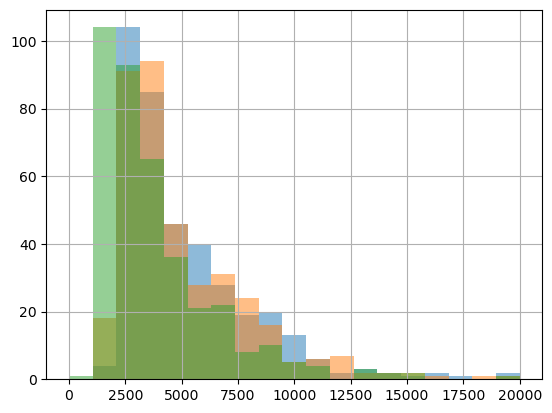

In [65]:
bins = np.linspace(0,20000,20)
fluxerr_fp.hist(bins=bins,alpha=0.5)
merged_all['fluxerr_ztf'].hist(bins=bins,alpha=0.5)
merged_all['fluxerr_lynx'].hist(bins=bins,alpha=0.5)

In [66]:
gain = 6.2
nea = GAUSS_EFF_AREA2FWHM_SQ * (merged_all["sciinpseeing"]) ** 2
err = np.sqrt(merged_all['flux_perfect']/merged_all['zp_nJy'] + (merged_all['scisigpix']*gain)**2*nea)*merged_all['zp_nJy']

<Axes: >

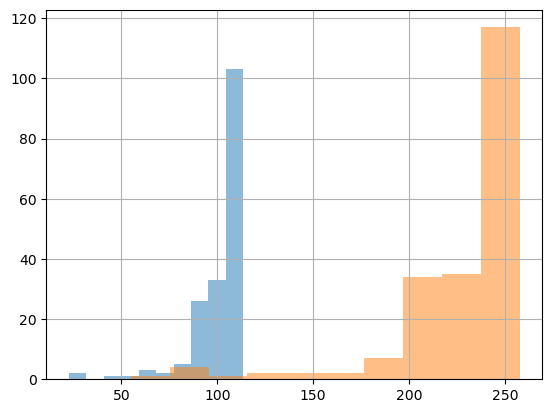

In [67]:
gidx = merged_all['filter'] == 'g'
merged_all[gidx]['scibckgnd_fp'].hist(alpha=0.5)
ridx = merged_all['filter'] == 'r'
merged_all[ridx]['scibckgnd_fp'].hist(alpha=0.5)

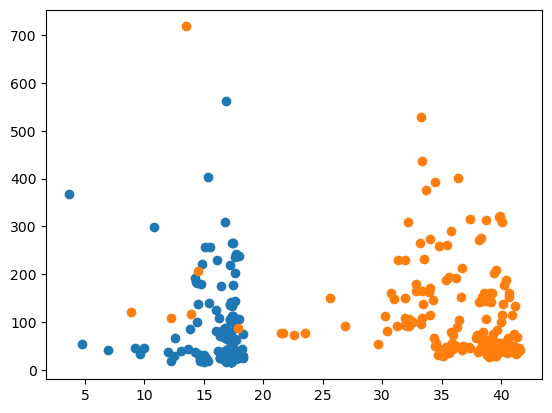

In [68]:
plt.plot(merged_all[gidx]['scibckgnd_fp']/gain,(merged_all[gidx]['scisigpix'])**2,'o')
plt.plot(merged_all[ridx]['scibckgnd_fp']/gain,(merged_all[ridx]['scisigpix'])**2,'o')

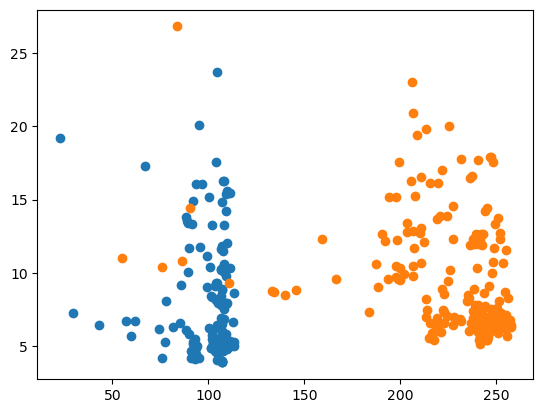

In [69]:
plt.plot(merged_all[gidx]['scibckgnd_fp'],(merged_all[gidx]['scisigpix']),'o')
plt.plot(merged_all[ridx]['scibckgnd_fp'],(merged_all[ridx]['scisigpix']),'o')

<Axes: >

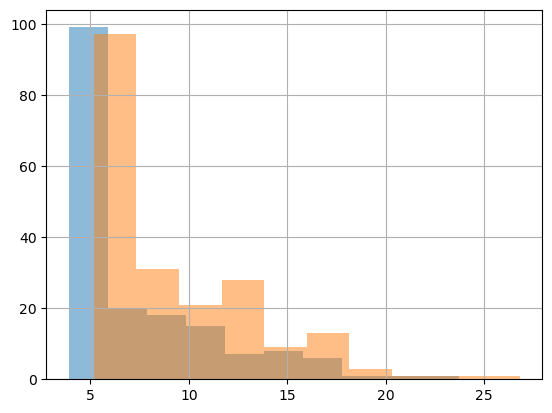

In [70]:
merged_all[gidx]['scisigpix'].hist(alpha=0.5)
merged_all[ridx]['scisigpix'].hist(alpha=0.5)

In [71]:
err2 = poisson_bandflux_std(merged_all['flux_perfect'],    
                     total_exposure_time = merged_all['exptime'],
                     exposure_count=1,
                     psf_footprint=nea,
                     sky=merged_all['scibckgnd_fp']*gain,
                     zp=merged_all['zp_nJy'],
                     readout_noise=8.,
                     dark_current=0.,
                     zp_err_mag=0.,)

<Axes: >

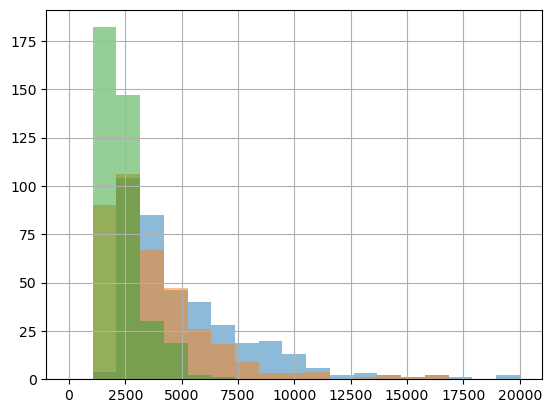

In [72]:
bins = np.linspace(0,20000,20)
fluxerr_fp.hist(bins=bins,alpha=0.5)
err.hist(bins=bins,alpha=0.5)
err2.hist(bins=bins,alpha=0.5)

In [73]:
err = poisson_bandflux_std(merged_all['flux_perfect'],    
                     total_exposure_time = merged_all['exptime'],
                     exposure_count=1,
                     psf_footprint=nea,
                     sky=merged_all['scibckgnd_fp']*gain,
                     zp=merged_all['zp_nJy'],
                     readout_noise=8.,
                     dark_current=0.,
                     zp_err_mag=0.,)

In [74]:
nea = GAUSS_EFF_AREA2FWHM_SQ * (merged_all["sciinpseeing"]) ** 2
merged_all['sqrtskytimesnea'] = np.sqrt(merged_all['scibckgnd_fp']*nea/gain)

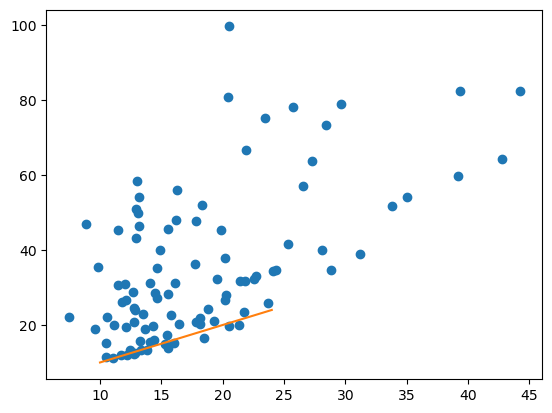

In [75]:
idx = (flux_fp/fluxerr_fp<1) & (flux_fp/fluxerr_fp >0)
merged_all['flux_perfect_adu'] = merged_all['flux_perfect']/merged_all['zp_nJy']/gain
merged_all['flux_lynx_adu'] = merged_all['flux_lynx']/merged_all['zp_nJy']/gain
merged_all['fluxerr_lynx_adu'] = merged_all['fluxerr_lynx']/merged_all['zp_nJy']/gain
merged_all['fluxerr_ztf_adu'] = merged_all['fluxerr_ztf']/merged_all['zp_nJy']/gain
df = merged_all[idx][['sqrtskytimesnea','scibckgnd_fp','skynoise','forcediffimflux','forcediffimfluxunc','flux_perfect_adu','flux_lynx_adu','fluxerr_lynx_adu','fluxerr_ztf_adu','maglimit','diffmaglim']]
plt.plot(df['sqrtskytimesnea'],df['skynoise'],'o')
plt.plot([10,24],[10,24])

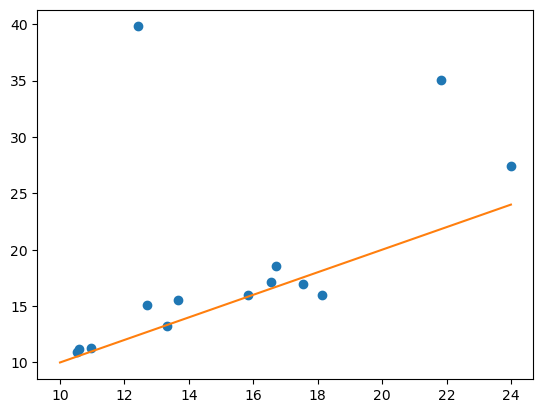

In [76]:
idx = flux_fp/fluxerr_fp>50
merged_all['flux_perfect_adu'] = merged_all['flux_perfect']/merged_all['zp_nJy']/gain
df = merged_all[idx][['sqrtskytimesnea','scibckgnd_fp','skynoise','forcediffimflux','forcediffimfluxunc','flux_perfect_adu','flux_lynx_adu','fluxerr_lynx_adu','fluxerr_ztf_adu','maglimit','diffmaglim']]
plt.plot(df['sqrtskytimesnea'],df['skynoise'],'o')
plt.plot([10,24],[10,24])

<Axes: >

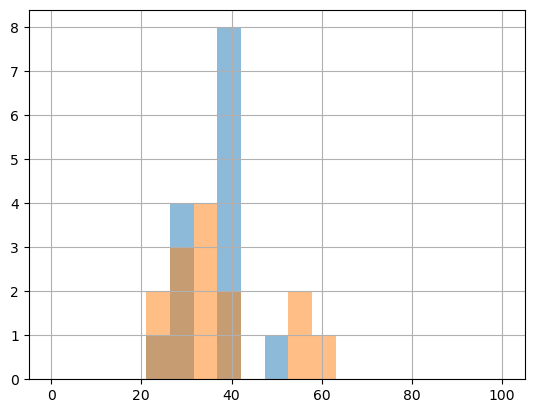

In [77]:
bins = np.linspace(0,100,20)
df.fluxerr_lynx_adu.hist(bins=bins,alpha=0.5)
df.fluxerr_ztf_adu.hist(bins=bins,alpha=0.5)

In [78]:
def get_single_fits_header(fname):
    hdu = fits.open(fname)
    h = hdu[0].header 
    colname = ['GAIN','READNOI','DARKCUR','MAGLIM','SEEING','EXPID','MAGZP','ZPAVG','OBSMJD']
    coldict = {}
    for col in colname:
        coldict[col]=h[col]
    return coldict

In [79]:
dlist = []
files = glob.glob('data/2020jny_images/**/*.fits',recursive=True)
for f in files:
    dlist.append(get_single_fits_header(f))
header_info = pd.DataFrame(dlist)

In [80]:
hdu = fits.open(files[0])
h = hdu[0].header 

In [81]:
from astropy.io import fits
import numpy as np
from typing import Dict, Any

def robust_sky_stats(data: np.ndarray, clip_sigma: float = 3.0, max_iter: int = 6):
    """
    Robustly estimate the sky background and its dispersion from a 2D image.

    Returns
    -------
    sky_adu : float
        Median sky level in ADU per pixel (DN/pix).
    sky_sigma_adu : float
        Robust scatter (MAD*1.4826) in ADU per pixel.
    n_used : int
        Number of pixels used after clipping.
    """
    x = data[np.isfinite(data)].ravel().astype(float)
    if x.size == 0:
        raise ValueError("No finite pixels in image.")

    for _ in range(max_iter):
        med = np.median(x)
        mad = np.median(np.abs(x - med))
        sig = 1.4826 * mad if mad > 0 else np.std(x)
        if not np.isfinite(sig) or sig == 0:
            break
        keep = (x > med - clip_sigma * sig) & (x < med + clip_sigma * sig)
        if keep.sum() == x.size:
            break
        if keep.sum() == 0:
            break
        x = x[keep]

    sky_adu = float(np.median(x))
    sky_sigma_adu = float(1.4826 * np.median(np.abs(x - sky_adu)))
    return sky_adu, sky_sigma_adu, int(x.size)

def ztf_sky_from_fits(path: str, ext: int = 0) -> Dict[str, Any]:
    """
    Compute sky background and related metrics for a ZTF image where MAGZP is in DN (per exposure).

    Parameters
    ----------
    path : str
        Path to FITS image.
    ext : int
        FITS extension to read.

    Returns
    -------
    dict with:
        - sky_median_DN_per_pix
        - sky_sigma_DN_per_pix
        - sky_median_electrons_per_pix
        - per_pixel_noise_electrons   (sqrt(sky + read^2 + dark))
        - sky_surface_brightness_mag_per_arcsec2
        - five_sigma_point_source_limit_mag
        - diagnostics (sub-dict with inputs and helper values)
    """
    h = fits.getheader(path, ext=ext)
    data = fits.getdata(path, ext=ext).astype(float)

    # ---- Required header values ----
    gain = float(h.get("GAIN"))          # e-/DN
    rdnoise = float(h.get("READNOI"))    # e-
    dark_e_per_s = float(h.get("DARKCUR", 0.0))  # e-/s/pix
    exptime = float(h.get("EXPTIME"))    # s
    pixscale = float(h.get("PIXSCALE"))  # arcsec/pix
    zp = float(h.get("MAGZP"))           # MAGZP in DN (per exposure)
    fwhm_pix = float(h.get("SEEING"))    # FWHM in pixels
    mjd = float(h.get("OBSMJD"))         # mjd
    filter = h.get("FILTER")     # filter
    
    # ---- Measure sky in DN/pix (a.k.a. ADU) ----
    sky_dn, sky_sig_dn, n_used = robust_sky_stats(data)

    # ---- Convert to electrons & per-pixel noise ----
    sky_e = sky_dn * gain                          # e-/pix
    dark_e = dark_e_per_s * exptime                # e-/pix (per exposure)
    sigma_e_pix = float(np.sqrt(max(sky_e, 0.0) + rdnoise**2 + max(dark_e, 0.0)))

    # ---- Sky surface brightness (mag/arcsec^2) with MAGZP in DN (per exposure) ----
    # mu = MAGZP - 2.5*log10( sky_DN_per_pix / pixscale^2 )
    # Guard against non-positive
    if sky_dn > 0 and pixscale > 0:
        mu_sky = float(zp - 2.5 * np.log10(sky_dn / (pixscale**2)))
    else:
        mu_sky = np.nan

    # ---- 5-sigma point-source limit using Gaussian NEA ----
    # NEA (in pixels) = 4*pi*sigma^2, where sigma = FWHM / 2.3548
    sigma_psf_pix = fwhm_pix / 2.354820045
    NEA = float(4.0 * np.pi * (sigma_psf_pix**2))
    # total noise for PSF-weighted flux in electrons
    sigma_e_src = np.sqrt(NEA * (max(sky_e, 0.0) + rdnoise**2 + max(dark_e, 0.0)))
    flux5_dn = (5.0 * sigma_e_src) / gain  # DN (per exposure)
    m5 = float(zp - 2.5 * np.log10(flux5_dn)) if flux5_dn > 0 else np.nan

    return {
        "sky_median_DN_per_pix": float(sky_dn),
        "sky_sigma_DN_per_pix": float(sky_sig_dn),
        "sky_median_electrons_per_pix": float(sky_e),
        "per_pixel_noise_electrons": sigma_e_pix,
        "sky_surface_brightness_mag_per_arcsec2": mu_sky,
        "five_sigma_point_source_limit_mag": m5,
        "MJD": mjd,
        "FILTER": filter,
        "n_pixels_used": n_used,
        "NEA_pix": NEA,
        "PSF_sigma_pix": float(sigma_psf_pix),
        "flux5_DN": float(flux5_dn) if np.isfinite(m5) else np.nan,
        "GAIN_e_per_DN": gain,
        "READNOISE_e": rdnoise,
        "DARK_e_per_s": dark_e_per_s,
        "EXPTIME_s": exptime,
        "PIXSCALE_arcsec_per_pix": pixscale,
        "MAGZP_DN": zp,
        "SEEING_FWHM_pix": fwhm_pix,
    }

# -------------------------
# Example usage:
# out = ztf_sky_from_fits("ztf_20220513348287_000575_zr_c10_o.fits")
# for k, v in out.items():
#     if k != "diagnostics":
#         print(f"{k}: {v}")
# print("diagnostics:", out["diagnostics"])


In [82]:
from astropy.io import fits
import numpy as np

def estimate_sky_quick(fits_path, ext=0, clip_sigma=3.0, clip_iters=5, mask_nan=True):
    """Return a robust scalar sky level [same units as the FITS data] and noise."""
    data = fits.getdata(fits_path, ext=ext).astype(float)
    h = fits.getheader(fits_path, ext=ext)

    if mask_nan:
        data = data[np.isfinite(data)]

    # Sigma-clip by hand (avoids extra dependencies)
    x = data.ravel()
    for _ in range(clip_iters):
        med = np.median(x)
        std = 1.4826 * np.median(np.abs(x - med))  # MAD -> robust sigma
        keep = (x > med - clip_sigma*std) & (x < med + clip_sigma*std)
        x = x[keep]
        if x.size == 0:
            raise ValueError("All pixels clipped; check image or parameters.")

    sky_median = np.median(x)
    sky_std = 1.4826 * np.median(np.abs(x - sky_median))
    # Optional crude mode estimate (SExtractor-esque)
    sky_mode = 3*sky_median - 2*np.mean(x)

    return {
        "sky_median": float(sky_median),
        "sky_mode_est": float(sky_mode),
        "sky_sigma": float(sky_std),
        "MJD": float(h.get("OBSMJD")),       # mjd
        "FILTER": h.get("FILTER")     # filter    
    }

# Example:
# res = estimate_sky_quick("image.fits")
# print(res)


In [83]:
from astropy.io import fits
import numpy as np
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground, SExtractorBackground
from photutils.segmentation import detect_threshold, detect_sources
from photutils.utils import circular_footprint
from scipy.ndimage import binary_dilation

def estimate_sky_map(
    fits_path,
    ext=0,
    box_size=64,          # tile size (pixels); tune to be > PSF and smaller than gradients
    filter_size=3,        # smooth the background tiles
    bkg_estimator="sex",  # "sex" (SExtractor) or "median"
    nsigma=3.0,           # sigma-clip for background calc
    source_mask=True,     # mask sources before background calc
    npixels=20,           # minimum connected pixels to call a detection
    dilate_psf=2          # grow the source mask by N pixels
):
    h = fits.getheader(fits_path, ext=ext)
    data = fits.getdata(fits_path, ext=ext).astype(float)

    # Choose background estimator
    if bkg_estimator.lower().startswith("sex"):
        estimator = SExtractorBackground()
    else:
        estimator = MedianBackground()

    sigclip = SigmaClip(sigma=nsigma, maxiters=10)

    mask = None
    if source_mask:
        # Build a simple detection mask to avoid sources
        # Use a rough global threshold; you can supply your own RMS if known.
        thresh = detect_threshold(data, nsigma=nsigma, sigma_clip=sigclip)
        segm = detect_sources(data, thresh, npixels=npixels)
        if segm is not None:
            mask = segm.data.astype(bool)
            if dilate_psf and dilate_psf > 0:
                fp = circular_footprint(dilate_psf)
                mask = binary_dilation(mask, structure=fp)

    bkg = Background2D(
        data,
        box_size=(box_size, box_size),
        filter_size=(filter_size, filter_size),
        sigma_clip=sigclip,
        bkg_estimator=estimator,
        mask=mask
    )

    # Scalar summaries (same units as the image)
    sky_mean = float(np.mean(bkg.background))
    sky_median = float(np.median(bkg.background))
    # RMS map: includes small-scale noise; sigma_clip helps robustness
    sky_rms_mean = float(np.mean(bkg.background_rms))
    sky_rms_median = float(np.median(bkg.background_rms))

    return {
        "sky_mean": sky_mean,
        "sky_median": sky_median,
        "sky_rms_mean": sky_rms_mean,
        "sky_rms_median": sky_rms_median,
        "background_map": bkg.background,       # 2D array
        "background_rms_map": bkg.background_rms,  # 2D array
        "mask": mask,                             # boolean mask used
        "MJD": float(h.get("OBSMJD")),       # mjd
        "FILTER": h.get("FILTER")     # filter    
    }

# Example:
# out = estimate_sky_map("image.fits", box_size=64, filter_size=3)
# print(out["sky_median"], out["sky_rms_median"])
# sky-subtracted image:
# img_sky_sub = fits.getdata("image.fits") - out["background_map"]


In [84]:
files = glob.glob('data/2020jny_images/**/*.fits',recursive=True)

In [85]:
dflist= []
for f in files[0:]:
    dflist.append(ztf_sky_from_fits(f))
df = pd.DataFrame(dflist)

In [86]:
# dflist2= []
# for f in files[0:]:
#     dflist2.append(estimate_sky_map(f))
# df2 = pd.DataFrame(dflist2)

In [87]:
# this is the same as ztf_sky_from_fits()
# dflist2= []
# for f in files[0:]:
#     dflist2.append(estimate_sky_quick(f))
# df2 = pd.DataFrame(dflist2)

In [88]:
# files25 = glob.glob('data/2020jny_images_25/**/*.fits',recursive=True)
# dflist3= []
# for f in files25[0:]:
#     dflist3.append(ztf_sky_from_fits(f))
# df3 = pd.DataFrame(dflist3)

In [89]:
# dflist4= []
# for f in files25[0:]:
#     dflist4.append(estimate_sky_map(f))
# df4 = pd.DataFrame(dflist4)

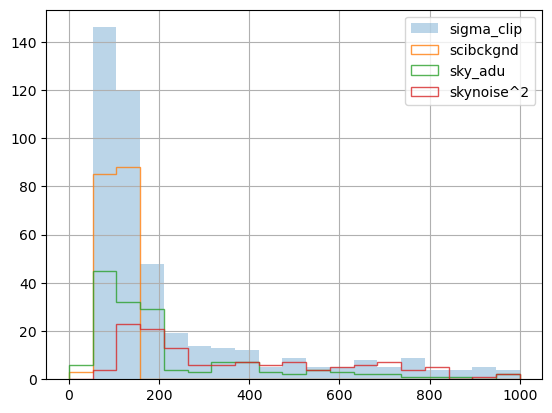

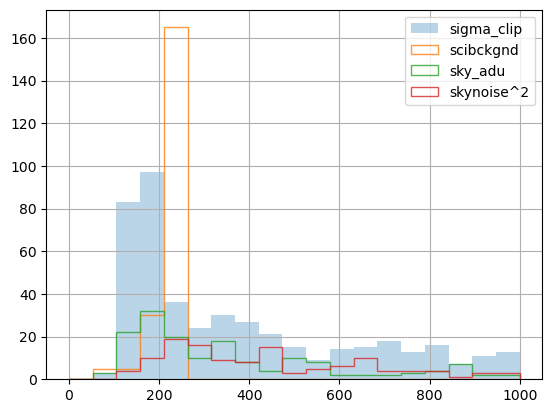

In [90]:
bins = np.linspace(0,1000,20)
idx = df['FILTER'] == "ZTF_g"
df.loc[idx,'sky_median_DN_per_pix'].hist(bins=bins,alpha=0.3,label='sigma_clip')
# idx = df2["FILTER"] == "ZTF_g"
# df2.loc[idx,'sky_median'].hist(bins=bins,alpha=0.3,label='photutil')
# idx = df3["FILTER"] == "ZTF_g"
# df3.loc[idx,'sky_median_DN_per_pix'].hist(bins=bins,alpha=0.3,label='photutil25',histtype='step')
# idx = df4["FILTER"] == "ZTF_g"
# df4.loc[idx,'sky_median'].hist(bins=bins,alpha=0.3,label='sigma_clip25',histtype='step')
idx = merged_all['filter'] == "g"
merged_all.loc[idx,'scibckgnd_fp'].hist(bins=bins,alpha=0.8,label='scibckgnd',histtype='step')
merged_all.loc[idx,'sky_adu'].hist(bins=bins,alpha=0.8,label='sky_adu',histtype='step')
(merged_all.loc[idx,'skynoise']**2).hist(bins=bins,alpha=0.8,label='skynoise^2',histtype='step')
plt.legend()
plt.show()

bins = np.linspace(0,1000,20)
idx = df['FILTER'] == "ZTF_r"
df.loc[idx,'sky_median_DN_per_pix'].hist(bins=bins,alpha=0.3,label='sigma_clip')
# idx = df2["FILTER"] == "ZTF_r"
# df2.loc[idx,'sky_median'].hist(bins=bins,alpha=0.3,label='photutil')
# idx = df3["FILTER"] == "ZTF_r"
# df3.loc[idx,'sky_median_DN_per_pix'].hist(bins=bins,alpha=0.3,label='photutil25')
# idx = df4["FILTER"] == "ZTF_r"
# df4.loc[idx,'sky_median'].hist(bins=bins,alpha=0.3,label='sigma_clip25')
idx = merged_all['filter'] == "r"
merged_all.loc[idx,'scibckgnd_fp'].hist(bins=bins,alpha=0.8,label='scibckgnd',histtype='step')
merged_all.loc[idx,'sky_adu'].hist(bins=bins,alpha=0.8,label='sky_adu',histtype='step')
(merged_all.loc[idx,'skynoise']**2).hist(bins=bins,alpha=0.8,label='skynoise^2',histtype='step')
plt.legend()

In [91]:
# from astropy.io import fits
# from astropy.nddata import Cutout2D
# from astropy.wcs import WCS

# def crop_center_fits(inpath, outpath, size=25, ext=0):
#     with fits.open(inpath) as hdul:
#         data = hdul[ext].data
#         hdr  = hdul[ext].header
#         wcs  = WCS(hdr)

#         ny, nx = data.shape
#         # pixel-center for even/odd sizes
#         x_c = (nx - 1) / 2.0
#         y_c = (ny - 1) / 2.0

#         cut = Cutout2D(
#             data, (x_c, y_c), (size, size),
#             wcs=wcs, mode="trim"  # trim if near edges
#         )

#         hnew = hdr.copy()
#         hnew.update(cut.wcs.to_header())   # update WCS to cropped frame
#         hnew["NAXIS1"] = cut.data.shape[1]
#         hnew["NAXIS2"] = cut.data.shape[0]

#         hdul[ext].data = cut.data
#         hdul[ext].header = hnew
#         hdul.writeto(outpath, overwrite=True)

# # Example:
# # crop_center_fits("in.fits", "center25.fits", size=25)


In [92]:
# for f in files[0:]:
#     crop_center_fits(f, f"data/2020jny_images_25/{f.split('/')[-1]}_25.fits", size=25)

<Axes: >

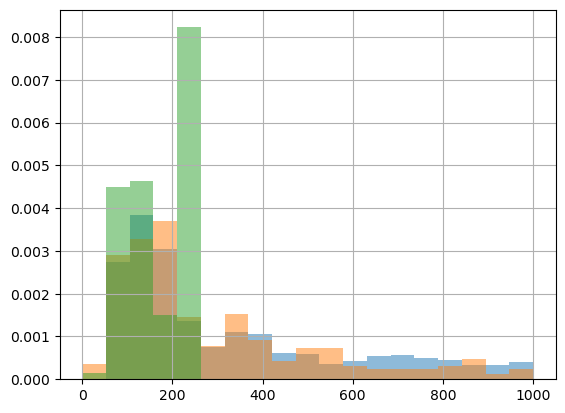

In [94]:
bins=np.linspace(0,1000,20)
df['sky_median_DN_per_pix'].hist(bins=bins,density=True,alpha=0.5)
# df2['sky_median'].hist(bins=bins,density=True,alpha=0.5)
merged_all['sky_adu'].hist(bins=bins,density=True,alpha=0.5)
merged_all['scibckgnd_fp'].hist(bins=bins,density=True,alpha=0.5)

<Axes: >

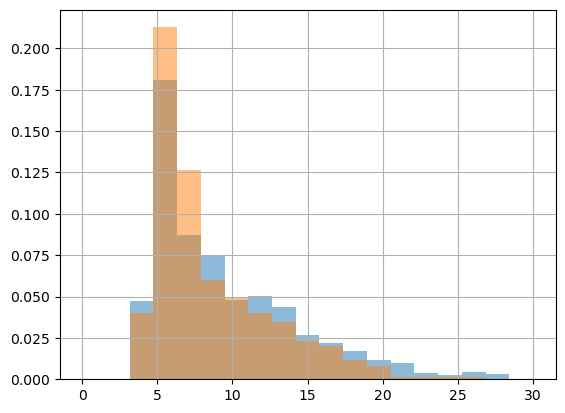

In [95]:
bins=np.linspace(0,30,20)
df['sky_sigma_DN_per_pix'].hist(bins=bins,density=True,alpha=0.5)
merged_all['scisigpix'].hist(bins=bins,density=True,alpha=0.5)
# df2['sky_rms_median'].hist(bins=bins,density=True,alpha=0.5)

In [96]:
df = df.rename(columns={"MJD":"mjd",
                        "FILTER":"filter"})
df['filter'] = [x[-1] for x in df['filter']]

In [97]:
merged_all_all = pd.merge_asof(
    merged_all.sort_values('mjd'),
    df.sort_values('mjd'),
    on='mjd',
    by=['filter'],
    direction='nearest',
    tolerance=0.01,
    suffixes = ('_merged','_manualsky'),
)

Text(0, 0.5, 'scibckgnd')

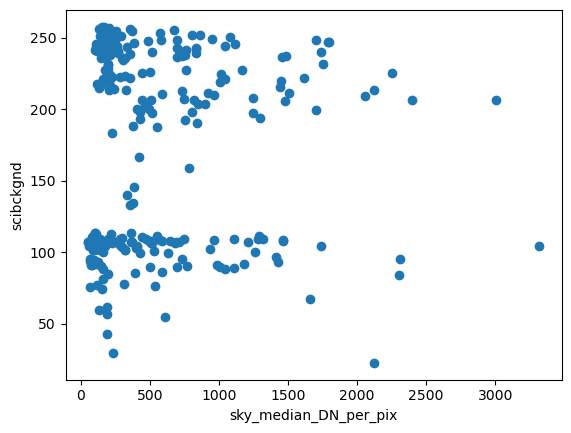

In [98]:
plt.plot(merged_all_all.sky_median_DN_per_pix,merged_all_all.scibckgnd_fp,'o')
# plt.plot([0,2000],[0,2000],c='k')
plt.xlabel('sky_median_DN_per_pix')
plt.ylabel('scibckgnd')

(0.0, 30.0)

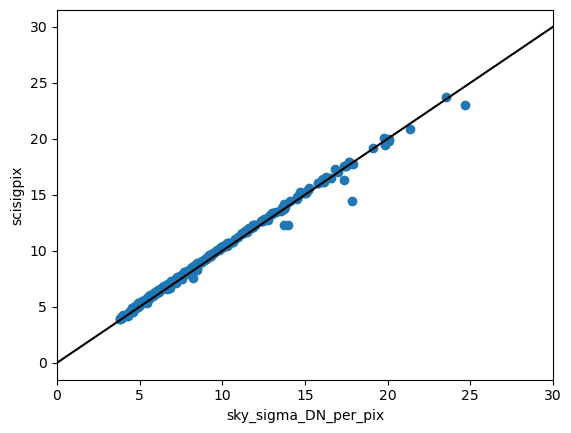

In [99]:
plt.plot(merged_all_all.sky_sigma_DN_per_pix,merged_all_all.scisigpix,'o')
plt.xlabel('sky_sigma_DN_per_pix')
plt.ylabel('scisigpix')
plt.plot([0,30],[0,30],c='k')
plt.xlim((0,30))

6.2


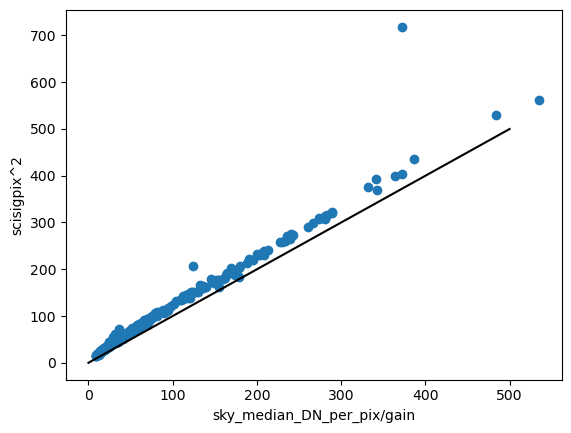

In [100]:
print(gain)
plt.plot(merged_all_all.sky_median_DN_per_pix/gain,merged_all_all.scisigpix**2,'o')
plt.xlabel('sky_median_DN_per_pix/gain')
plt.ylabel('scisigpix^2')
plt.plot([0,500],[0,500],c='k')

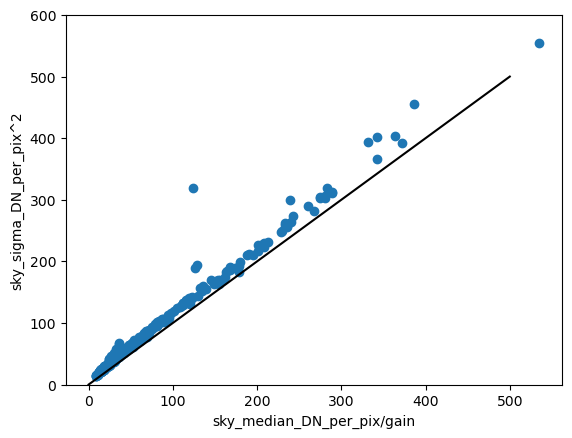

In [101]:
plt.plot(merged_all_all.sky_median_DN_per_pix/gain,merged_all_all.sky_sigma_DN_per_pix**2,'o')
plt.xlabel('sky_median_DN_per_pix/gain')
plt.ylabel('sky_sigma_DN_per_pix^2')
plt.ylim((0,600))
plt.plot([0,500],[0,500],c='k')

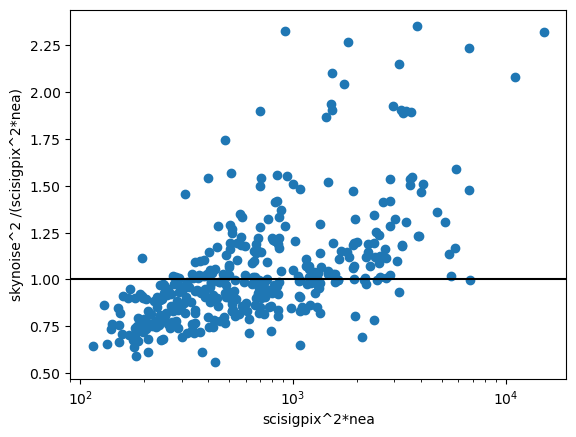

In [102]:
nea = GAUSS_EFF_AREA2FWHM_SQ * (merged_all_all["sciinpseeing"]) ** 2
plt.plot(merged_all_all.scisigpix**2*nea,merged_all_all.skynoise**2/merged_all_all.scisigpix**2/nea,'o')
plt.xlabel('scisigpix^2*nea')
plt.ylabel('skynoise^2 /(scisigpix^2*nea)')
plt.axhline(y=1,c='k')
plt.xscale('log')